# ASTR 19 Exoplanet Mass Project: 55 Cnc

**Author:** Anthony Saucedo

This notebook loads radial velocity data for **55 Cnc**, plots the data with error bars, fits a sinusoidal model, examines the residuals, and uses the fitted amplitude and period to estimate the mass of the detected exoplanet.

## 1. Import the libraries

We will use:
- `numpy` for calculations
- `pandas` for organizing the data
- `matplotlib` for graphs
- `scipy.optimize.curve_fit` to fit the sinusoidal model
- `scipy.signal.lombscargle` to estimate the dominant period in the data

In [41]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import lombscargle

## 2. Load the radial velocity data

This code first looks for a local copy of the dataset. If it is not present, it downloads the 274-point radial velocity file from the NASA Exoplanet Archive.

The file contains:
- HJD = observation time in days
- Radial velocity in m/s
- Radial velocity uncertainty in m/s

In [42]:
url = 'https://exoplanetarchive.ipac.caltech.edu/data/ExoData/0043/0043587/data/UID_0043587_RVC_008.tbl'
filename = '55Cnc_RV_274.tbl'

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)

rows = []
with open(filename, 'r') as file:
    for line in file:
        stripped = line.strip()
        if not stripped or stripped.startswith('\\') or stripped.startswith('|'):
            continue
        parts = stripped.split()
        if len(parts) == 3:
            rows.append(tuple(map(float, parts)))

data = pd.DataFrame(rows, columns=['HJD', 'Radial_Velocity', 'Radial_Velocity_Uncertainty'])
data.head()

,HJD,Radial_Velocity,Radial_Velocity_Uncertainty
0,2.449676e+06,131.910004,4.84
1,2.449768e+06,22.600000,2.57
2,2.449769e+06,-5.490000,2.68
3,2.449794e+06,107.309998,1.52
4,2.450057e+06,116.669998,1.62


## 3. Plot the radial velocity data

This graph shows the measured radial velocity of the star as a function of time. The error bars represent the experimental uncertainty on each measurement.

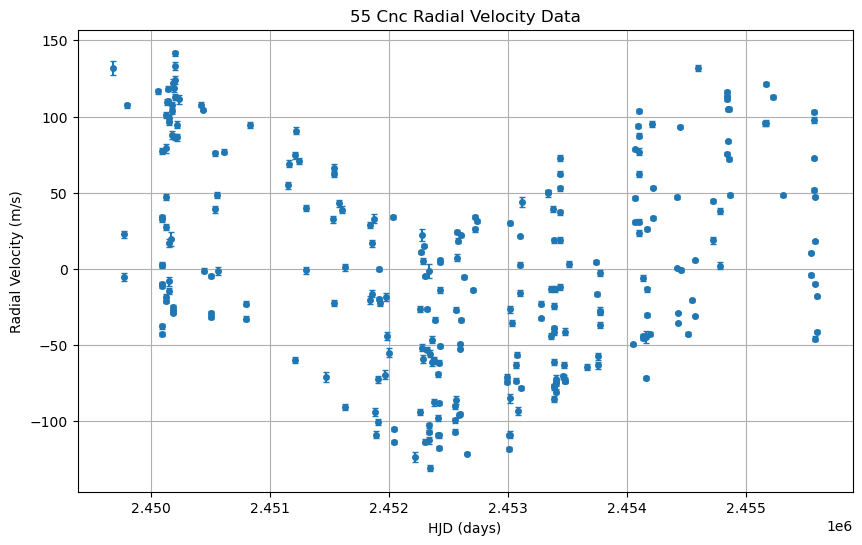

In [43]:
plt.figure(figsize=(10, 6))
plt.errorbar(
    data['HJD'],
    data['Radial_Velocity'],
    yerr=data['Radial_Velocity_Uncertainty'],
    fmt='o',
    markersize=4,
    capsize=2
)
plt.xlabel('HJD (days)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('55 Cnc Radial Velocity Data')
plt.grid(True)
plt.show()

## 4. Estimate the dominant period in the data

Before fitting the sinusoidal model, we use a Lomb-Scargle periodogram to estimate the strongest period in the radial velocity measurements.

In [44]:
t = data['HJD'].values
rv = data['Radial_Velocity'].values
rv_err = data['Radial_Velocity_Uncertainty'].values

t_rel = t - t.min()

# Search periods between 2 and 200 days
freq = np.linspace(1/200, 1/2, 100000)
power = lombscargle(t_rel, rv - rv.mean(), 2 * np.pi * freq, precenter=True, normalize=True)
best_period_guess = 1 / freq[np.argmax(power)]

print(f'Best period guess from the periodogram: {best_period_guess:.4f} days')

Best period guess from the periodogram: 14.6516 days


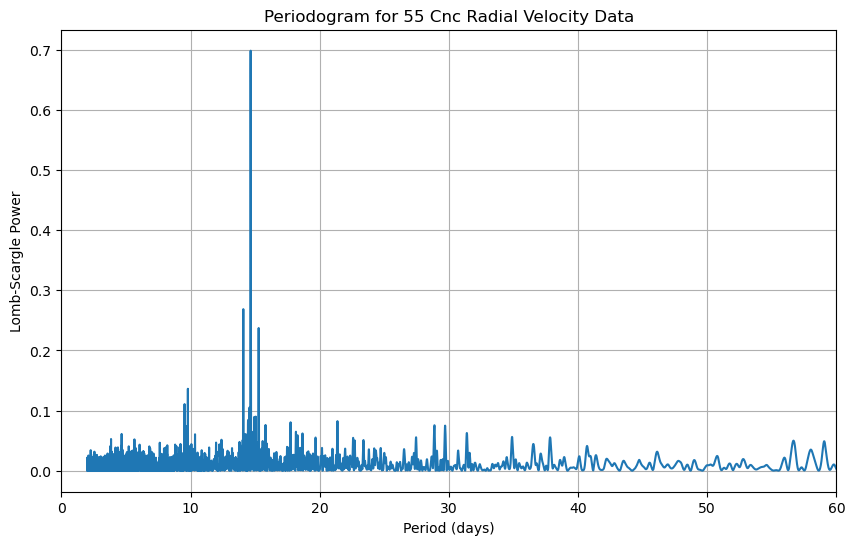

In [45]:
periods = 1 / freq

plt.figure(figsize=(10, 6))
plt.plot(periods, power)
plt.xlim(0, 60)
plt.xlabel('Period (days)')
plt.ylabel('Lomb-Scargle Power')
plt.title('Periodogram for 55 Cnc Radial Velocity Data')
plt.grid(True)
plt.show()

## 5. Define and fit a sinusoidal model

We model the radial velocity signal with a sinusoidal function:

$$RV(t) = K \sin\left(\frac{2\pi t}{P} + \phi\right) + \gamma$$

where:
- $K$ is the amplitude in m/s
- $P$ is the period in days
- $\phi$ is the phase
- $\gamma$ is a constant offset

In [46]:
def sinusoid(t, K, P, phi, gamma):
    return K * np.sin(2 * np.pi * t / P + phi) + gamma

initial_guess = [75, best_period_guess, 0.0, rv.mean()]

params, covariance = curve_fit(
    sinusoid,
    t_rel,
    rv,
    p0=initial_guess,
    sigma=rv_err,
    absolute_sigma=True,
    maxfev=100000
)

parameter_errors = np.sqrt(np.diag(covariance))

K_fit, P_fit, phi_fit, gamma_fit = params
K_err, P_err, phi_err, gamma_err = parameter_errors

print(f'K = {K_fit:.3f} ± {K_err:.3f} m/s')
print(f'P = {P_fit:.5f} ± {P_err:.5f} days')
print(f'phi = {phi_fit:.3f} ± {phi_err:.3f}')
print(f'gamma = {gamma_fit:.3f} ± {gamma_err:.3f} m/s')

K = 74.494 ± 0.129 m/s
P = 14.65147 ± 0.00004 days
phi = 1.890 ± 0.004
gamma = 4.556 ± 0.093 m/s


## 6. Plot the data and the best-fit model together

This graph compares the measured data to the fitted sinusoidal model.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# sinusoid model
def sinusoid(t, A, omega, phi, C):
    return A * np.sin(omega*t + phi) + C

# data
t = np.array(t)
rv = np.array(rv)

t_rel = t - t.min()

# initial guesses
A_guess = (rv.max() - rv.min()) / 2
C_guess = np.mean(rv)
T_guess = t_rel.max() - t_rel.min()
omega_guess = 2*np.pi / T_guess
phi_guess = 0

p0 = [A_guess, omega_guess, phi_guess, C_guess]

# fit
params, covariance = curve_fit(sinusoid, t_rel, rv, p0=p0)

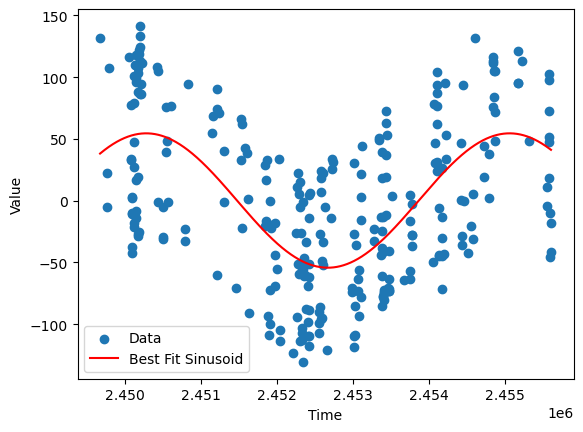

In [55]:
t_smooth_rel = np.linspace(t_rel.min(), t_rel.max(), 5000)
t_smooth = t_smooth_rel + t.min()

rv_fit_smooth = sinusoid(t_smooth_rel, *params)

plt.scatter(t, rv, label="Data")
plt.plot(t_smooth, rv_fit_smooth, label="Best Fit Sinusoid", color="red")

plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## 7. Compute and plot the residuals

The residuals are the differences between the measured radial velocities and the best-fit model.

$$\text{residual} = RV_{\text{data}} - RV_{\text{model}}$$

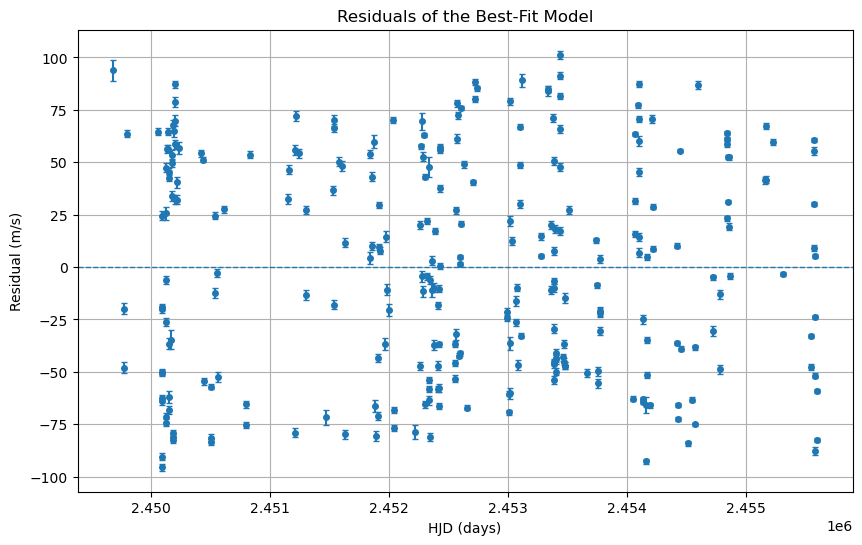

In [49]:
rv_fit = sinusoid(t_rel, *params)
residuals = rv - rv_fit

plt.figure(figsize=(10, 6))
plt.axhline(0, linestyle='--', linewidth=1)
plt.errorbar(t, residuals, yerr=rv_err, fmt='o', markersize=4, capsize=2)
plt.xlabel('HJD (days)')
plt.ylabel('Residual (m/s)')
plt.title('Residuals of the Best-Fit Model')
plt.grid(True)
plt.show()

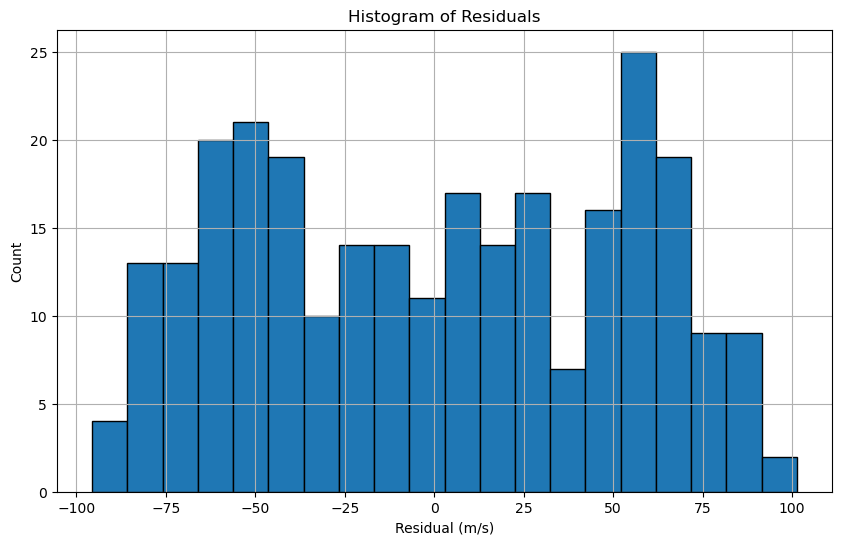

Standard deviation of residuals = 52.046 m/s
Mean experimental uncertainty = 1.806 m/s
Median experimental uncertainty = 1.695 m/s


In [50]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Residual (m/s)')
plt.ylabel('Count')
plt.title('Histogram of Residuals')
plt.grid(True)
plt.show()

residual_std = np.std(residuals, ddof=1)
mean_uncertainty = np.mean(rv_err)
median_uncertainty = np.median(rv_err)

print(f'Standard deviation of residuals = {residual_std:.3f} m/s')
print(f'Mean experimental uncertainty = {mean_uncertainty:.3f} m/s')
print(f'Median experimental uncertainty = {median_uncertainty:.3f} m/s')

## 8. Calculate the planet mass

For a circular orbit and zero inclination, the project gives the approximate mass formula:

$$M_{\mathrm{planet}} = \left(\frac{K}{28.4\,\mathrm{m/s}}\right)\left(\frac{P}{365\,\mathrm{days}}\right)^{1/3}(M_{\star})^{2/3}$$

where:
- $K$ is the fitted amplitude in m/s
- $P$ is the fitted period in days
- $M_{\star}$ is the stellar mass in solar masses
- the result is in Jupiter masses

For 55 Cnc, we use a stellar mass of **0.905 solar masses**.

In [51]:
M_star = 0.905
M_planet_jup = (K_fit / 28.4) * (P_fit / 365.0)**(1/3) * (M_star**(2/3))

print(f'Estimated planet mass = {M_planet_jup:.3f} Jupiter masses')

Estimated planet mass = 0.840 Jupiter masses


## 9. Interpretation

The best-fit period is about **14.65 days**, which matches **55 Cnc b**.

The fitted mass is close to the known mass of 55 Cnc b, so the sinusoidal signal in this dataset is consistent with that planet.

The residual standard deviation is much larger than the average experimental uncertainty, which suggests that a single-sinusoid model does not capture all of the structure in the data. This makes sense because the 55 Cnc system contains multiple planets, so the star's motion is affected by more than one orbiting body.

## 10. Short conclusion

In this project, I used radial velocity data from 55 Cnc to identify a strong periodic signal and fit it with a sinusoidal model. From the fit, I found a period near 14.65 days and used the fitted amplitude to estimate a planet mass of about 0.84 Jupiter masses. This is consistent with the known exoplanet **55 Cnc b**.